<a href="https://colab.research.google.com/github/Yangel300/BreathIA/blob/CAT/Breath_IA_v7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#Instalacion de paquetes y librerias
!pip install opendatasets
!pip install pandas

In [21]:
import librosa
import IPython.display as ipd
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Audio
import soundfile as sf
from numpy import pi
import os
import requests
import platform
import time
import timeit
import opendatasets as od
import shutil
import math
import pandas as pd
from scipy import signal
from scipy.fft import fftshift, fft, fftfreq

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'respiratory-sound-database' dataset.
Path to dataset files: /kaggle/input/respiratory-sound-database


In [10]:
audio_path="/kaggle/input/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"

test1="107_2b5_Lr_mc_AKGC417L"

audio1_waw=audio_path+"/"+test1+".wav"
audio1_text=audio_path+"/"+test1+".txt"

In [11]:
def graph_audio(audio):
  y=audio[0]
  sr=audio[1]
  y=y/np.max(np.abs(y))
  dt=y.size/sr
  plt.figure(figsize=(3.8, 2.8))
  plt.subplot()
  plt.grid()
  plt.xlim(0,dt)
  plt.ylim(-1.1,1.1)
  librosa.display.waveshow(y, sr=sr)
  plt.xlabel('tiempo [s]')
  plt.ylabel('amplitud[/]')

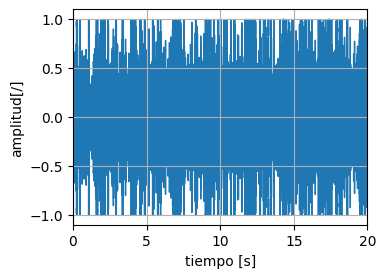

In [12]:
audio1=librosa.load(audio1_waw)

graph_audio(audio1)
Audio(audio1[0],rate=22050)

In [23]:
"""
scipy.fft.fft(x, n=None, axis=-1,
    norm=None, overwrite_x=False, workers=None, *, plan=None)

    x : array_like
        The input array.

    n : int, optional
        The length of the FFT to be used if n

    axis : int, optional
        The axis along which to apply the FFT

    norm : {'backward', 'forward', 'ortho'}, optional
        The normalization mode

    overwrite_x: bool, optional
        If True, the contents of x can be destroyed

    workers : int, optional
        The number of worker threads to use for the FFT.

    plan : int, optional
        The FFTW plan to use.



fftfreq(n, d=1.0, *, xp=None, device=None)
      d: scalar, optional
        Sample spacing (inverse of the sampling rate).

      xp: array_namespace, optional
        The namespace for the return array.

      device: device, optional
        The device for the return array.
    """

def fft1D(audio):
  y=audio[0]
  sr=audio[1]
  yf=fft(y)
  xf=fftfreq(y.size,d=1/sr)

  return[xf,yf]

def grap_fft(fft):
  xf=fft[0]
  yf=fft[1]
  half_n=int(yf.size/2)
  plt.figure(figsize=(3.8, 2.8))
  plt.subplot()
  plt.grid()
  plt.plot(xf[:half_n],np.abs(yf[:half_n]))
  plt.xlabel('frecuencia [Hz]')
  plt.ylabel('amplitud[/]')
  plt.xlim(0,100)


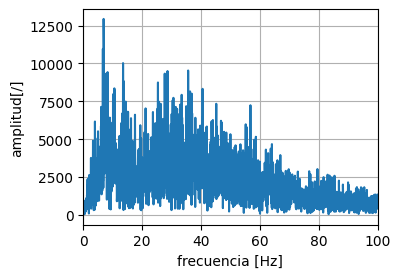

In [24]:
ff=fft1D(audio1)
grap_fft(ff)

In [46]:
"""
scipy.fft.fft(x, n=None, axis=-1,
    norm=None, overwrite_x=False, workers=None, *, plan=None)

    x : array_like
        The input array.

    n : int, optional
        The length of the FFT to be used if n

    axis : int, optional
        The axis along which to apply the FFT

    norm : {'backward', 'forward', 'ortho'}, optional
        The normalization mode

    overwrite_x: bool, optional
        If True, the contents of x can be destroyed

    workers : int, optional
        The number of worker threads to use for the FFT.

    plan : int, optional
        The FFTW plan to use.



fftfreq(n, d=1.0, *, xp=None, device=None)
      d: scalar, optional
        Sample spacing (inverse of the sampling rate).

      xp: array_namespace, optional
        The namespace for the return array.

      device: device, optional
        The device for the return array.
    """

def fft1D(audio):
  y=audio[0]
  sr=audio[1]
  yf=fft(y)
  xf=fftfreq(y.size,d=1/sr)

  return[xf,yf]

def grap_fft(fft):
  xf=fft[0]
  yf=fft[1]
  half_n=int(yf.size/2)
  plt.figure(figsize=(3.8, 2.8))
  plt.subplot()
  plt.grid()
  plt.plot(xf[:half_n],np.abs(yf[:half_n]))
  plt.xlabel('frecuencia [Hz]')
  plt.ylabel('amplitud[/]')
  plt.xlim(0,100)

def fft_window_size(audio, w_size):
  N_samples=w_size*audio[1]
  N_samples=int(N_samples)
  y=audio[0][:N_samples]
  sr=audio[1]
  yf=fft(y)
  xf=fftfreq(y.size,d=1/sr)

  return[xf,yf]

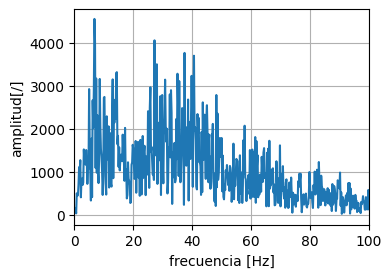

In [53]:
fft2=fft_window_size(audio1,5)
grap_fft(fft2)

22050
44100
66150
88200
110250
132300


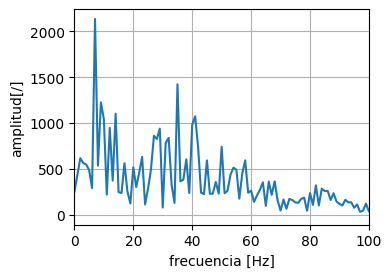

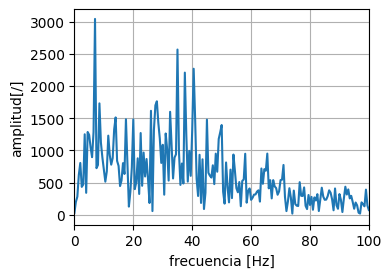

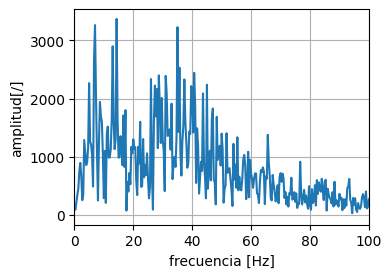

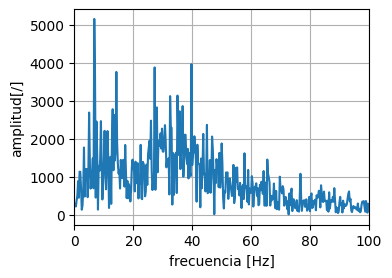

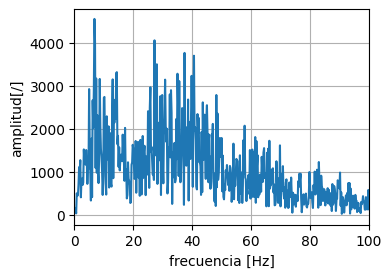

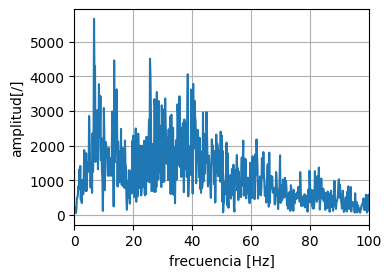

In [58]:
windows=[1,2,3,4,5,6]

for i in windows:
  fft_w=fft_window_size(audio1,i)
  print(len(fft_w[0]))
  grap_fft(fft_w)

In [62]:
from scipy.fft import rfft
from scipy.interpolate import interp1d

def fft_resample(yf, xf, target_bins):
    # Compute magnitude of FFT
    X_magnitude = np.abs(yf)

    # Target grid
    target_freqs = np.linspace(0, xf[-1], target_bins) # Use the max frequency from the original FFT

    # Interpolate
    f = interp1d(xf, X_magnitude, kind="linear", fill_value="extrapolate")
    X_resampled = f(target_freqs)
    return target_freqs, X_resampled

22050
66150
44100
66150
66150
66150
88200
66150
110250
66150
132300
66150


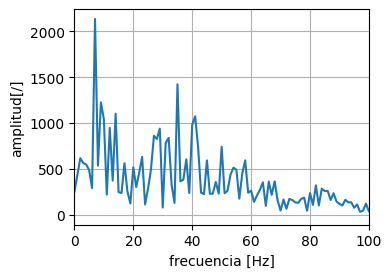

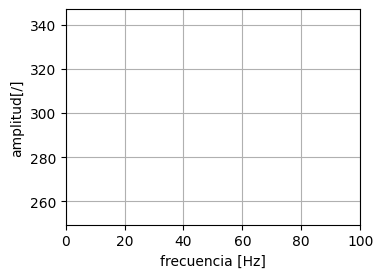

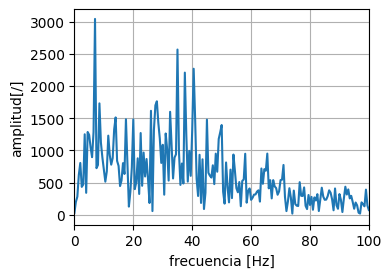

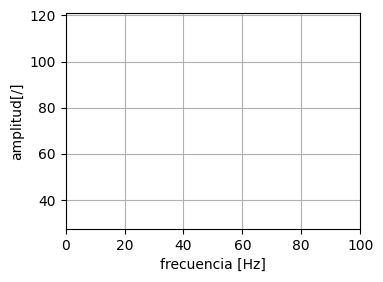

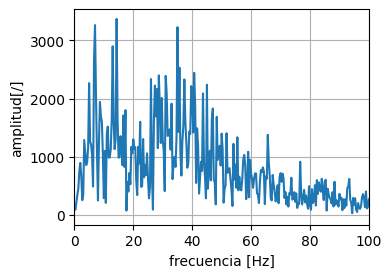

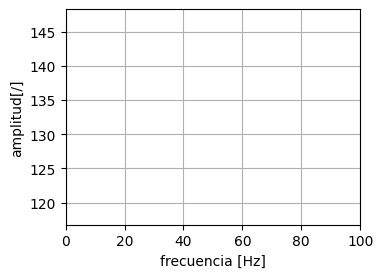

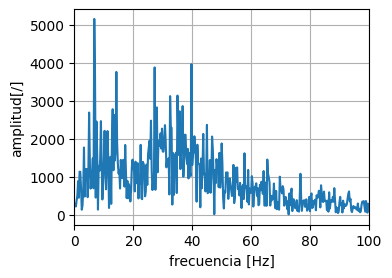

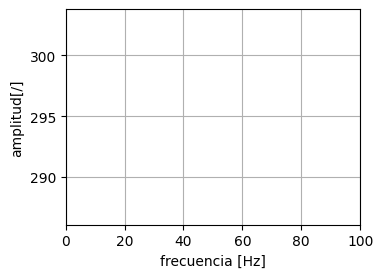

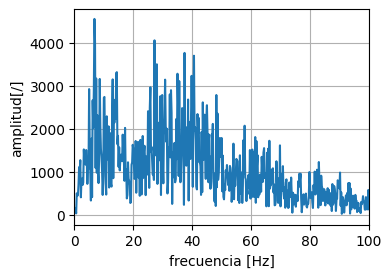

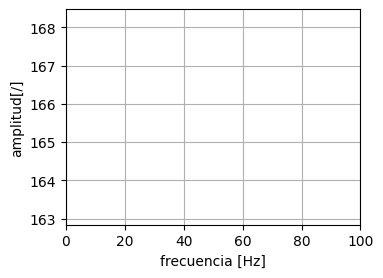

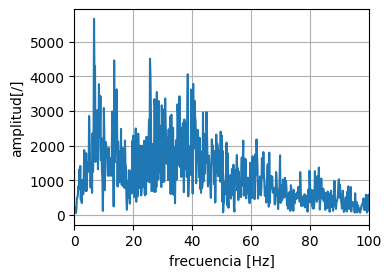

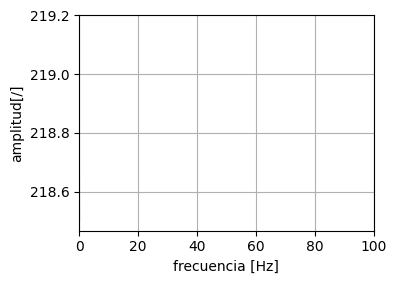

In [67]:
for i in windows:
  fft_w=fft_window_size(audio1,i)
  print(len(fft_w[0]))
  grap_fft(fft_w)
  fft_w=fft_resample(fft_w[1],fft_w[0],66150)
  grap_fft(fft_w)
  print(len(fft_w[0]))